In [1]:
import os
import sys
import numpy as np
import time
import scipy
import matplotlib.pyplot as plt
import time

In [2]:
# frank1d
import frank
from frank.geometry import FixedGeometry, SourceGeometry, FitGeometryGaussian
from frank.radial_fitters import FrankFitter
from frank.utilities import UVDataBinner
from frank.utilities import convolve_profile

In [3]:
# import the frank2d directory
current_dir =  os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

#frank2d
from frank2d.frank2d import Frank2D 
from frank2d.geometry import Geometry
from frank2d.constants import rad_to_arcsec
from frank2d.plot import Plot
from frank2d.fitting import IterativeSolverMethod

In [4]:
from scipy.special import j0
from scipy.stats import binned_statistic

In [5]:
from scipy.optimize import curve_fit

### Functions

In [6]:
def gauss(r, sigma):
    return np.exp(-0.5*((r-rout/2.)/sigma)**2)

### Load data

In [7]:
AS209 = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3, 'rout': 1.9, 'disk_name': 'AS209'}
IMLup = {'inc': 47.5, 'pa': 144.5, 'dra':-1.5e-3, 'ddec':1e-3, 'rout': 1.71*2, 'disk_name': 'IMLup'}
Elias27 = {'inc': 56.2, 'pa': 118.8, 'dra':-5e-3, 'ddec':-8e-3, 'rout': 1.88*2, 'disk_name': 'Elias27'}
HD163296 = {'inc':46.7, 'pa':133.33, 'dra':-2.8e-3, 'ddec':7.7e-3, 'rout':1.7*2, 'disk_name': 'HD163296' }
Elias24 = {'inc': 29, 'pa': 45.7, 'dra':110.8e-3, 'ddec':-386.8e-3, 'rout': 1.03*2, 'disk_name': 'Elias24'}
HD143006 = {'inc': 18.6, 'pa': 169, 'dra':-5.9e-3, 'ddec':21.7e-3, 'rout': 0.518*3, 'disk_name': 'HD143006'}

In [8]:
data = AS209

# UVtable
dir = "/Users/mariajmelladot/Desktop/Frank2D/data/uvtables/"
disk_name = data['disk_name']
data_file = dir +"uvtable_" + disk_name + "_continuum.npz"

# Load data
file = np.load(data_file)
u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
Vis = Re + Im*1j

In [9]:
# Huang 2018 
inc = data['inc']
pa = data['pa']
dra = data['dra']
ddec = data['ddec']
rout = data['rout']

In [10]:
geom_f2d = Geometry(inc, pa, dra, ddec)
geom_Ring = geom_f2d

### Create the ring in uv-space

In [11]:
# Deprojection
du, dv, _ = geom_f2d.deproject(u, v)
dbaseline = np.hypot(du, dv)

baseline = np.hypot(u, v)

In [12]:
baseline_ring = baseline
u_ring = u
v_ring = v

In [13]:
Re_ring = np.median(Re[np.where(baseline_ring<3e4)])*np.real(j0(2.*np.pi*(rout/rad_to_arcsec/2.)*baseline_ring))

In [14]:
Imag_ring = np.zeros(len(Re))
Vis_ring = Re_ring + Imag_ring*1j

In [15]:
N = 300

### Frank2D

In [16]:
frank2d = Frank2D(N, rout, geom_f2d)

Shifted grid..
Setting gridded data...
Setting GP Kernel Wendland...
Creating sparse linear system...
--> time kernel = 0.01  min |  0.86 seconds
--> time = 0.01  min |  0.87 seconds
Solving linear system...
         * rtol: 1e-08
         * final tolerance: 2.6079480261539363
Final tolerance :  2.6079480261539363
.... iteration:  0
                        -> actual tol:  260794802.6153936 vs  2.6079480261539363
converged by norm of s


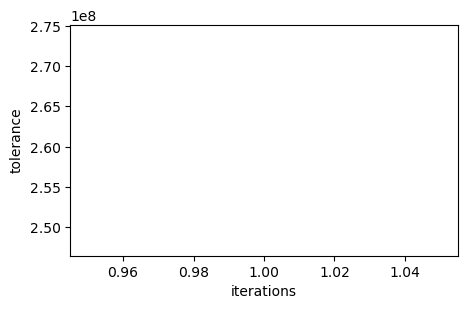

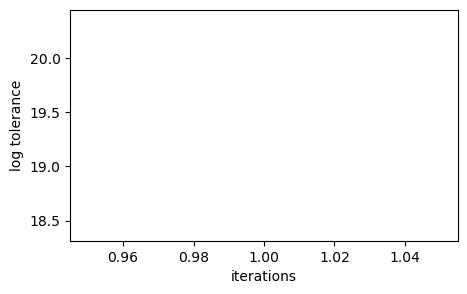

--> time = 0.01  min |  0.61 seconds
               ---> CGM converged?   True
                    ---> Fit correctly?   True
                     !!!!  Sucess..  !!!!
Building full visibility model...


In [17]:
kernel_params =  {'m': -2, 'c': 10**8, 'l': 1e4}
uvtable = {'u': u_ring, 'v': v_ring, 'vis': Vis_ring, 'weights': Weights}
frank2d.process_vis(uvtable)
frank2d.fit(kernel_params = kernel_params, rtol = 1e-8 )

### Best

In [18]:
#frank2d.search_MAP()

In [19]:
best = frank2d.MAP

Setting GP Kernel Wendland...
Creating sparse linear system...
--> time kernel = 0.02  min |  1.39 seconds
--> time = 0.02  min |  1.42 seconds
Solving linear system...
         * rtol: 1e-08
         * final tolerance: 2.6079480261539363
Final tolerance :  2.6079480261539363
.... iteration:  0
                        -> actual tol:  260794802.6153936 vs  2.6079480261539363
.... iteration:  1
                        -> actual tol:  32984165.147225343 vs  2.6079480261539363
.... iteration:  2
                        -> actual tol:  18859499.640132308 vs  2.6079480261539363
.... iteration:  3
                        -> actual tol:  11775726.831357785 vs  2.6079480261539363
.... iteration:  4
                        -> actual tol:  11095691.121148014 vs  2.6079480261539363
.... iteration:  5
                        -> actual tol:  83188275.48730019 vs  2.6079480261539363
.... iteration:  6
                        -> actual tol:  2412751.365756613 vs  2.6079480261539363
.... iteration:  7


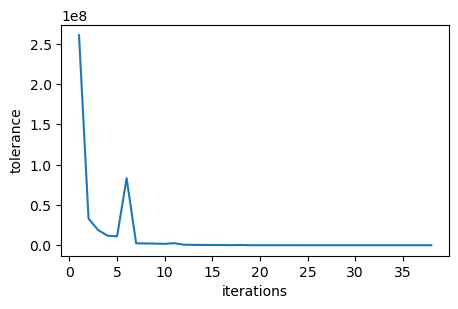

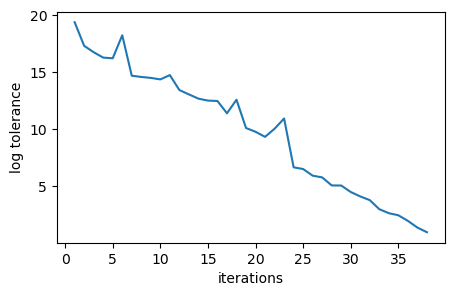

--> time = 0.01  min |  0.64 seconds
               ---> CGM converged?   True
                    ---> Fit correctly?   True
                     !!!!  Sucess..  !!!!
Building full visibility model...


In [20]:
frank2d.fit(run_from_scratch = True, kernel_params = best, rtol = 1e-8)

### Plot

In [21]:
Plot_ = Plot(frank2d, geom_f2d)

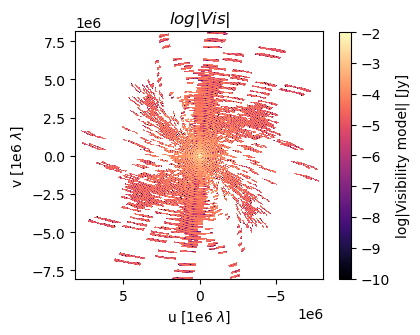

In [22]:
Plot_.visibility(fig_size = 4, kind = 'input')

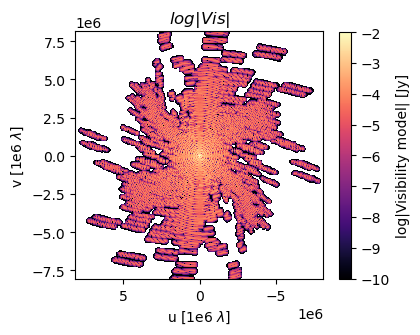

In [23]:
Plot_.visibility(fig_size = 4)

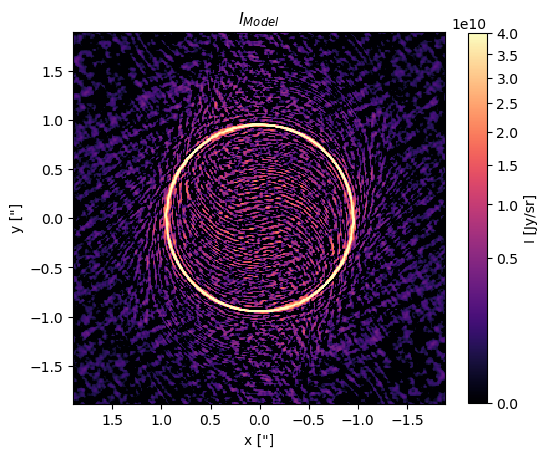

In [24]:
Plot_.intensity(fig_size = 6, phase_shift=True)

### FWHM

In [25]:
# deproject
x_model_1d, y_model_1d = geom_f2d.deproject_xy(Plot_._x_model_1d, Plot_._y_model_1d)
x_model, y_model = Plot_._x_model, Plot_._y_model

In [26]:
I = Plot_._int_model

In [27]:
r_ = np.unique(np.hypot(x_model_1d, y_model_1d))
bins = 900
r = np.linspace(r_.min(), r_.max(), bins)
edges = Plot_.edges(r)

In [28]:
r_f2d, I_f2d = Plot_.get_profile(x_model, y_model, I, bins = edges)

In [29]:
I_f2d = np.nan_to_num(I_f2d, nan=0)

In [30]:
popt_frank2d, cov = curve_fit(gauss, r_f2d, I_f2d/np.max(I_f2d), p0=[0.09])
FWHM_frank2d = popt_frank2d[0]* 2. *np.sqrt(2.*np.log(2.))
Error_FWHM_f2d = np.sqrt(cov[0][0])* 2. *np.sqrt(2.*np.log(2.)) 

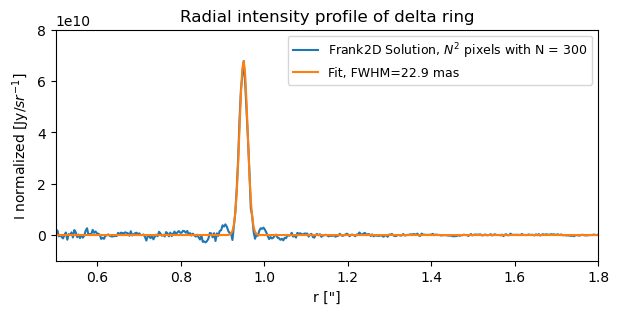

In [31]:
plt.close()
plt.figure(figsize=(7,3))
plt.plot(r_f2d, I_f2d, color='C0',label= r'Frank2D Solution, $N^{2}$ pixels with N = ' + str(N))
plt.plot(r_f2d, gauss(r_f2d, *popt_frank2d)*np.max(I_f2d), color='C1', label='Fit, FWHM=%.1f mas'%(FWHM_frank2d*1000))
plt.ylabel(r'I normalized [Jy/$sr^{-1}$]')
plt.xlabel('r ["]')
plt.xlim(0.5, 1.8)
plt.ylim(-1e10, 8e10)

plt.title('Radial intensity profile of delta ring')
plt.legend(loc='best', fontsize = 9)

In [32]:
print ('FWHM=', FWHM_frank2d, '+/-', Error_FWHM_f2d, 'arcsec')   

FWHM= 0.022905863089907247 +/- 0.00018714488952234127 arcsec


### Frank1D

In [33]:
# UVtable
dir = "../../../data/uvtables/"
data_file = dir +'uvtable_' + disk_name + '_continuum_1d.txt'

 # load data||
u_f1d, v_f1d, Re_f1d, Imag_f1d, Weights_f1d = u, v, Re, Im, Weights
Vis_f1d = Re_f1d + Imag_f1d*1j

In [34]:
u_f1d_d, v_f1d_d, _ = geom_f2d.deproject(u_f1d, v_f1d)
dbaseline_f1d = np.hypot(u_f1d_d, v_f1d_d)
baseline_f1d = np.hypot(u_f1d, v_f1d)

In [35]:
baseline_ring_f1d = dbaseline_f1d

In [36]:
Re_ring = np.median(Re_f1d[np.where(baseline_ring_f1d<3e4)])*np.real(j0(2.*np.pi*(rout/rad_to_arcsec/2.)*baseline_ring_f1d))

In [37]:
Imag_ring = np.zeros(len(Re_ring))
Vis_f1d = Re_ring + Imag_ring*1j

In [38]:
rout

1.9

In [39]:
# Frank 1D parameters
n_pts = 300
alpha = 1.2
w_smooth = 1e-3

geom = SourceGeometry(inc= inc, PA= pa, dRA= dra, dDec= ddec)
FF = FrankFitter(rout, n_pts, geom, alpha = alpha, weights_smooth = w_smooth)
sol = FF.fit(u_f1d, v_f1d, Vis_f1d, Weights_f1d)

In [40]:
r_f1d = sol.r
I_f1d = sol.mean

In [41]:
Plot_2 = Plot(frank2d, geom_f2d)

r_ = np.unique(np.hypot(x_model_1d, y_model_1d))
bins = 900
r = np.linspace(r_.min(), r_.max(), bins)
edges = Plot_.edges(r)

r_f1d, I_f1d = Plot_.get_profile(sol.r, sol.r, sol.mean, bins = edges, fit_1d = True)

I_f1d = np.nan_to_num(I_f1d, nan=0)

In [42]:
popt_frank1d, cov_frank1d = curve_fit(gauss, r_f1d, I_f1d/np.max(I_f1d), p0=[0.02])
FWHM_frank1d = popt_frank1d[0]* 2. *np.sqrt(2.*np.log(2.))
Error_FWHM_frank1d = np.sqrt(cov_frank1d[0][0])* 2. *np.sqrt(2.*np.log(2.))

In [43]:
print ('FWHM=', FWHM_frank1d, '+/-', Error_FWHM_frank1d, 'arcsec')   

FWHM= 0.011191120375380921 +/- 0.0003316039300556467 arcsec


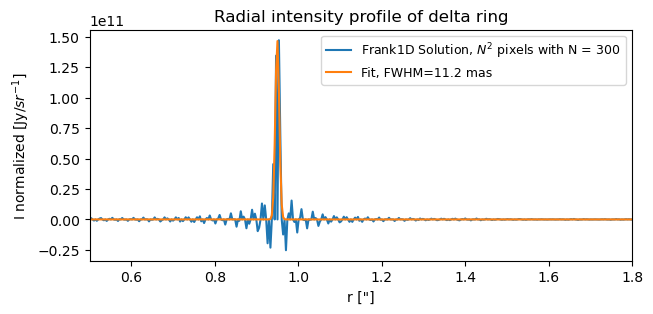

In [44]:
plt.close()
plt.figure(figsize=(7,3))
plt.plot(r_f1d, I_f1d, color='C0',label= r'Frank1D Solution, $N^{2}$ pixels with N = ' + str(n_pts))
plt.plot(r_f1d, gauss(r_f1d, *popt_frank1d)*np.max(sol.mean), color='C1', label='Fit, FWHM=%.1f mas'%(FWHM_frank1d*1000))
plt.ylabel(r'I normalized [Jy/$sr^{-1}$]')
plt.xlabel('r ["]')
plt.xlim(0.5, 1.8)
plt.title('Radial intensity profile of delta ring')
plt.legend(loc='best', fontsize = 9)

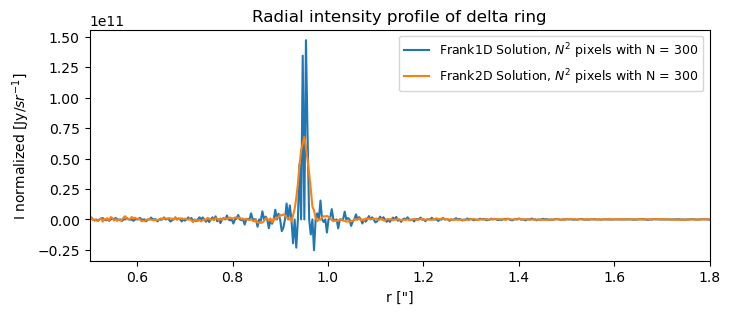

In [45]:
plt.close()
plt.figure(figsize=(8,3))
plt.plot(r_f1d, I_f1d,label= r'Frank1D Solution, $N^{2}$ pixels with N = ' + str(n_pts))
plt.plot(r_f2d, I_f2d, label= r'Frank2D Solution, $N^{2}$ pixels with N = ' + str(N))
plt.ylabel(r'I normalized [Jy/$sr^{-1}$]')
plt.xlabel('r ["]')
plt.xlim(0.5, 1.8)
plt.title('Radial intensity profile of delta ring')
plt.legend(loc='best', fontsize = 9)

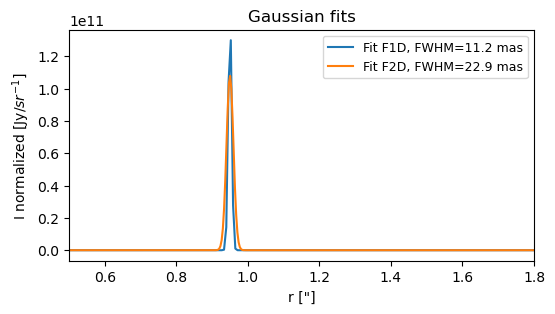

In [46]:
plt.close()
plt.figure(figsize=(6,3))
plt.plot(sol.r, gauss(sol.r, *popt_frank1d)*np.max(sol.mean), label='Fit F1D, FWHM=%.1f mas'%(FWHM_frank1d*1000))
plt.plot(r, gauss(r, *popt_frank2d)*np.max(I), label='Fit F2D, FWHM=%.1f mas'%(FWHM_frank2d*1000))
plt.ylabel(r'I normalized [Jy/$sr^{-1}$]')
plt.xlabel('r ["]')
plt.xlim(.5, 1.8)
plt.title('Gaussian fits')
plt.legend(loc='best', fontsize = 9)

### Convolve to the f2d beam

In [47]:
sigma_final = np.sqrt(FWHM_frank2d**2 - FWHM_frank1d**2)
sigma_final

0.019985929766646062

In [48]:
beam_1mm = {'bmaj':sigma_final, 'bmin':sigma_final, 'beam_pa':geom.PA}
convolved_frank1d = convolve_profile(r_f1d, I_f1d, geom.inc, geom.PA, beam_1mm)

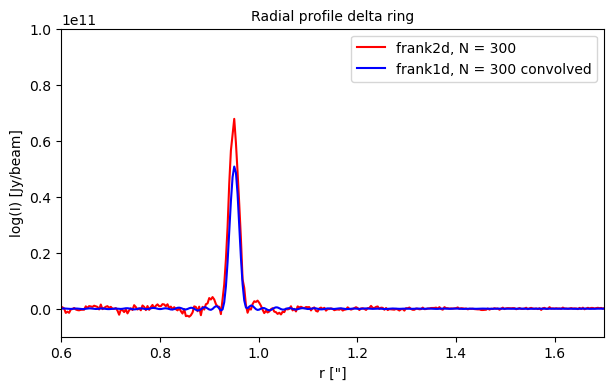

In [49]:
plt.figure(figsize=(7, 4))
plt.plot(r_f2d, I_f2d, "red", label=r'frank2d' + ', N = ' +str(n_pts))
plt.plot(r_f1d, convolved_frank1d, "blue", label=r'frank1d' + ', N = ' +str(N)+ ' convolved')
plt.title(r'Radial profile delta ring', size=10)
plt.ylabel("log(I) [Jy/beam]", size=10)
plt.xlabel('r ["]', size=10)
plt.xlim(0.6, 1.7)
plt.ylim(-1e10, 10e10)
plt.legend(fontsize=10)
plt.show()

In [50]:
popt_frank1d_conv, cov_frank1d_conv = curve_fit(gauss, r_f1d, convolved_frank1d/np.max(convolved_frank1d), p0=[0.009])
FWHM_frank1d_conv = popt_frank1d_conv[0]* 2. *np.sqrt(2.*np.log(2.))
Error_FWHM_frank1d_conv = np.sqrt(cov_frank1d[0][0])* 2. *np.sqrt(2.*np.log(2.))

In [51]:
FWHM_frank1d_conv

0.02154033651395299

### Trying with real disk

In [11]:
u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
Vis = Re + Im*1j

In [12]:
N = 300
best = {'m': -1.011407337728121, 'c': 222.9257843669846, 'l': 46452.74921193543}

In [13]:
geom = Geometry(inc, pa, dra, ddec)
frank2d = Frank2D(N, rout, geom)

In [14]:
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights}

Shifted grid..
Setting gridded data...
Setting GP Kernel Wendland...
Creating sparse linear system...
--> time kernel = 0.02  min |  1.37 seconds
--> time = 0.02  min |  1.41 seconds
Solving linear system...
         * rtol: 1e-08
         * final tolerance: 3.5986215447871888
Final tolerance :  3.5986215447871888
.... iteration:  0
                        -> actual tol:  359862154.4787189 vs  3.5986215447871888
.... iteration:  1
                        -> actual tol:  16248311.289388938 vs  3.5986215447871888
.... iteration:  2
                        -> actual tol:  12793022.141465731 vs  3.5986215447871888
.... iteration:  3
                        -> actual tol:  17458649.174258534 vs  3.5986215447871888
.... iteration:  4
                        -> actual tol:  3767348.9717458216 vs  3.5986215447871888
.... iteration:  5
                        -> actual tol:  5315434.46853328 vs  3.5986215447871888
.... iteration:  6
                        -> actual tol:  1524640.4976162645 vs 

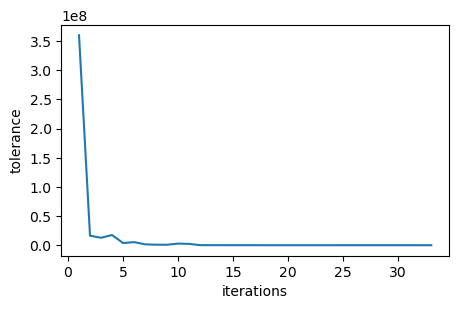

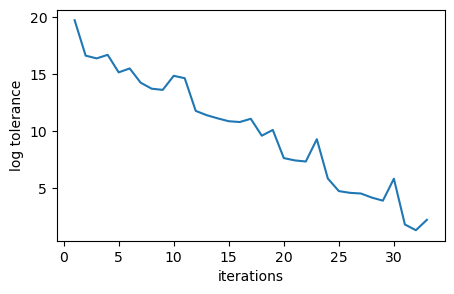

--> time = 0.02  min |  0.93 seconds
               ---> CGM converged?   True
                    ---> Fit correctly?   False
Building full visibility model...
F2D model in 28.01 seconds.


In [15]:
start_time = time.time()


frank2d.fit(data = uvtable, kernel_params = best, rtol = 1e-8 )

end_time = time.time()
print(f"F2D model in {(end_time - start_time):.2f} seconds.")

In [16]:
FWHM_frank2d = 0.022905863089907247
FWHM_frank1d = 0.011191120375380921

In [17]:
Plot_ = Plot(frank2d, geom)

In [18]:
from astropy.io import fits
dir =  "/Users/mariajmelladot/Desktop/Frank2D/data/fits/"
disk = disk_name + '_continuum.fits'

fits_name = dir + disk

In [19]:
Plot_.set_fits_file(fits_name)

In [20]:
sol_f1d = frank2d.frank1d(uvtable, alpha=1.2, w_smooth=1e-3, n_pts=300, rout=rout, geom=geom)

Performing 1D Frank fit...

$\alpha$ =  1.2  and $w_{smooth}$ =  0.001

N =  300  and $R_{max}$ =  1.9


In [21]:
Plot_.set_f1d_solution(sol_f1d)

	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
Clean beam: 0.038216292858108 x 0.036224924027904 arcsec
FWHM for frank2d: 0.022905863089907247 arcsec
-> Final beam to convolve with: 0.03059095415189107 x 0.028063616248335515 arcsec
FWHM for frank1d: 0.011191120375380921 arcsec
-> Final beam to convolve with: 0.0365409888284432 x 0.034452923614276196 arcsec


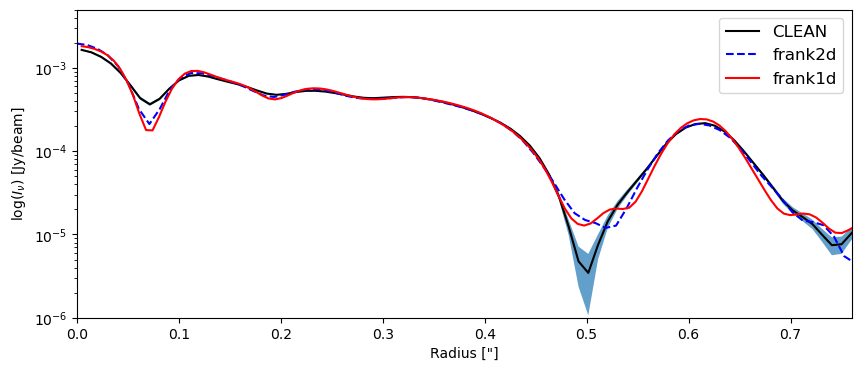

In [22]:
Plot_.intensity_profile(   clean = True, frank1d = True,
                            resol_f2d = FWHM_frank2d, resol_f1d = FWHM_frank1d
                        )

UnboundLocalError: cannot access local variable 'y_lims_sr' where it is not associated with a value

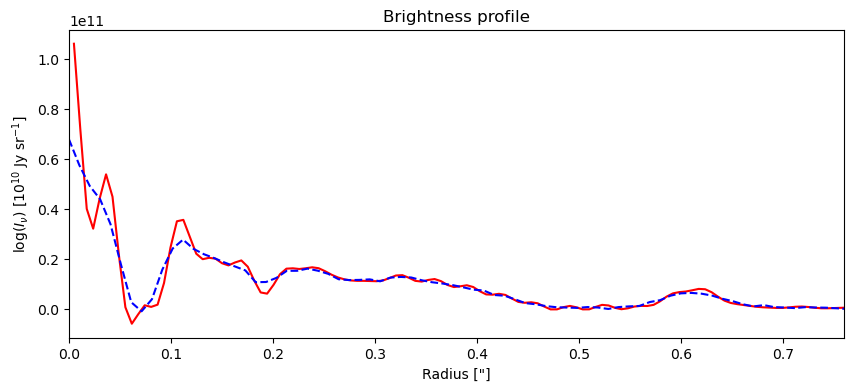

In [24]:
Plot_.intensity_profile(   clean = False, frank1d = True,
                            resol_f2d = FWHM_frank2d, resol_f1d = FWHM_frank1d, 
                            y_lims = (1e8, 1e12)
                        )